In [2]:
import logging
import random

import numpy as np
import torch
import torch.nn as nn

from vasae.models.sae import VASAE
from vasae.data.dataset import GPT2LayerActivations
from vasae.models.factory import get_blackbox_model
from vasae.metrics.logitlens import LogitLens

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import pandas as pd
import pyarrow.dataset as ds

logging.basicConfig(
    format="[%(levelname)s] %(asctime)s %(message)s",
    level=logging.INFO,
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger()

In [3]:
class CFG:
    seed = 42
    k = 20  # topk sparsity for SAE

    meta_path = "/scratch/b5bq/pu22650.b5bq/activations_gpt2_Geralt-Targaryen_openwebtext2/meta.json"
    layer_name = "transformer.h.5"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model_name = "gpt2"
    save_dir = "out"
    save_filename = "loss_data.pkl"
    num_epochs = 20


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [4]:
args = CFG()
set_seed(args.seed)
dataset = GPT2LayerActivations(args.meta_path, args.layer_name)
gpt2, tokenizer = get_blackbox_model("gpt2", "cuda")
logitlens = LogitLens(unembed_layer=gpt2.lm_head)

/home/b5bq/pu22650.b5bq/miniforge3/envs/qwen/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# layer_i,example_i,seq_i,token,probs
# 5,80,0, the,0.917
# draw: example_i,layer_i,seq_i,token,probs 每个sample写成一个文件

In [ ]:
sample_size = 200
num_layers = 30
seq_len = 64
values = 2

sample_size * num_layers * seq_len * values # 内存中应该可以放下，内存非常大，暂时不考虑，如果报错，在进行处理。我们直接在内存中交换是最快的

768000

In [13]:
h_l = dataset[80:81]
# logits = logitlens.project(h_l) # torch.Size([1, 64, 50257])
token_ids, token_probs, logits, probs = logitlens.top1(h_l) # torch.Size([1, 64])

save_list = []
for batch_id in range(token_ids.size(0)):
    for token_i in range(token_ids.size(1)):
        token = tokenizer.decode(token_ids[batch_id][token_i])
        print(f"'{token}'", f"{token_probs[batch_id][token_i].item():.3f}")
        save_list.extend([token_i,token,token_probs[batch_id][token_i].item()])

' the' 0.917
' (' 0.738
'th' 0.907
' the' 0.996
',' 0.999
' �' 0.519
' The' 0.642
' the' 0.559
' A' 0.537
'-' 0.999
'-' 0.968
',' 1.000
' the' 0.999
' night' 0.928
' the' 1.000
' "' 1.000
''s' 0.998
' "' 0.770
' the' 0.997
' the' 0.852
' "' 0.657
',' 0.972
' in' 0.990
' the' 1.000
' "' 0.936
'-' 1.000
'level' 0.965
',' 0.930
'-' 0.971
'-' 0.872
',' 0.926
' the' 1.000
' the' 0.955
' the' 1.000
',' 0.937
' year' 0.991
',' 0.887
' the' 0.985
' the' 0.998
' the' 1.000
'-' 1.000
'.' 0.752
'.' 0.975
'
' 0.980
'
' 0.897
'The' 0.986
'The' 0.939
' the' 0.967
' other' 0.980
'-' 0.996
' the' 1.000
',' 1.000
',' 0.635
' a' 0.546
' a' 0.730
' the' 0.659
'-' 0.991
',' 0.988
' the' 1.000
',' 0.999
' the' 1.000
' have' 0.546
' the' 0.991
' of' 0.752


# Visualize SAE

In [ ]:
sae = VASAE(
    k=args.k,
    embedding_weight=gpt2.transformer.wte.weight,
).to(args.device)
sae.load_state_dict(torch.load("/home/b5bq/pu22650.b5bq/work/VASAE/out/VASAE_BatchKSparse_gpt2_transformer_h_5_openwebtext_wocen.pth"))

<All keys matched successfully>

In [6]:
h_l = h_l.to(args.device)
with torch.no_grad():
    sae_activations = sae.encoder(h_l)
    topk, indices = torch.topk(sae_activations[0,-1,:], args.k)
for token_id, w in zip(indices, topk):
    print(tokenizer.decode(token_id), '\t', w.item())

 more 	 0.5859609246253967
 The 	 0.5403321981430054
 now 	 0.5152741074562073
. 	 0.49310386180877686
 has 	 0.43995869159698486
 be 	 0.4047691226005554
 new 	 0.37210848927497864
 B 	 0.2919258773326874
 w 	 0.263248085975647
 honor 	 0.25685036182403564
 gel 	 0.1908201277256012
C 	 0.14711353182792664
 and 	 0.12515372037887573
 ACT 	 0.00932714156806469
 to 	 -0.01847800426185131
uphem 	 -0.22261926531791687
fleet 	 -0.22645920515060425
hai 	 -0.23854410648345947
cheon 	 -0.24718263745307922
 quadru 	 -0.2621645927429199


In [7]:
with torch.no_grad():
    decoded, _ = sae(h_l.to(args.device))
nn.MSELoss()(h_l.to(args.device), decoded) # loss

tensor(0.4130, device='cuda:0')

# Logitlens Vis

In [38]:
save_dir = "../out/logitlens"
example_i = 1

In [40]:


dataset = ds.dataset("../out/logitlens", format="parquet")

scanner = dataset.scanner(
    filter=ds.field("example_i") == example_i,
    columns=["layer_i", "seq_i", "token", "prob"]
)

df = scanner.to_table().to_pandas() # layer_i,seq_i,token,prob

In [41]:
df

,layer_i,seq_i,token,prob
0,0,0,the,1.000000
1,0,1,'s,0.885101
2,0,2,true,0.448478
3,0,3,the,0.999973
4,0,4,-,0.910318
...,...,...,...,...
379,5,59,-,0.993596
380,5,60,",",0.902460
381,5,61,\n,0.999940
382,5,62,\n,0.995416


In [8]:


def clip_cmap(base_cmap, lo=0.1, hi=0.75, n=256):
    colors = base_cmap(np.linspace(lo, hi, n))
    return LinearSegmentedColormap.from_list(
        f"{base_cmap.name}_clip", colors
    )

cmap = clip_cmap(plt.cm.Blues, lo=0.08, hi=0.75)

In [43]:
seq_keep = df.seq_i.drop_duplicates().iloc[:8]
df8 = df[df.seq_i.isin(seq_keep)]

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_logit_lens(
    df,
    x_tokens,
    title=None,
    fontsize=9,
    dpi=300,
    cbar_ticks=(0, 0.2,0.4, 0.6,0.8,1),
):
    layers = sorted(df.layer_i.unique())
    seqs   = sorted(df.seq_i.unique())

    prob = (df.pivot(index="layer_i", columns="seq_i", values="prob")
              .reindex(index=layers, columns=seqs))
    tok  = (df.pivot(index="layer_i", columns="seq_i", values="token")
              .reindex(index=layers, columns=seqs))

    # 上高层，下低层
    Z = prob.to_numpy()[::-1]
    T = tok.to_numpy()[::-1]
    y_labels = layers[::-1]

    H, W = Z.shape
    fig_w = max(1.2, 0.9 * W)
    fig_h = max(1.2, 0.45 * H)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)

    norm = mcolors.Normalize(Z.min(), Z.max())
    cmap = clip_cmap(plt.cm.Blues, lo=0.1, hi=0.7)

    im = ax.imshow(
        Z,
        cmap=cmap,
        norm=norm,
        interpolation="none",   # ✅ 不糊
        aspect="auto",
        origin="upper",
    )

    # cell text
    for i in range(H):
        for j in range(W):
            ax.text(
                j, i, T[i, j],
                ha="center", va="center",
                fontsize=fontsize,
            )

    # x: token
    ax.set_xticks(range(W))
    ax.set_xticklabels(x_tokens, fontsize=fontsize)
    ax.tick_params(axis="x", pad=4)

    # y: layer index（只标关键层，防挤）
    yt = np.linspace(0, H-1, min(6, H), dtype=int)
    ax.set_yticks(yt)
    ax.set_yticklabels([y_labels[i] for i in yt], fontsize=fontsize)

    # 去边框 / 网格
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0)
    ax.grid(False)

    if title:
        ax.set_title(title, fontsize=fontsize+1, pad=6)

    # colorbar：手动刻度
    cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_ticks(cbar_ticks)
    cbar.ax.tick_params(labelsize=fontsize)

    plt.tight_layout(rect=[0, 0, 0.97, 1])
    plt.show()

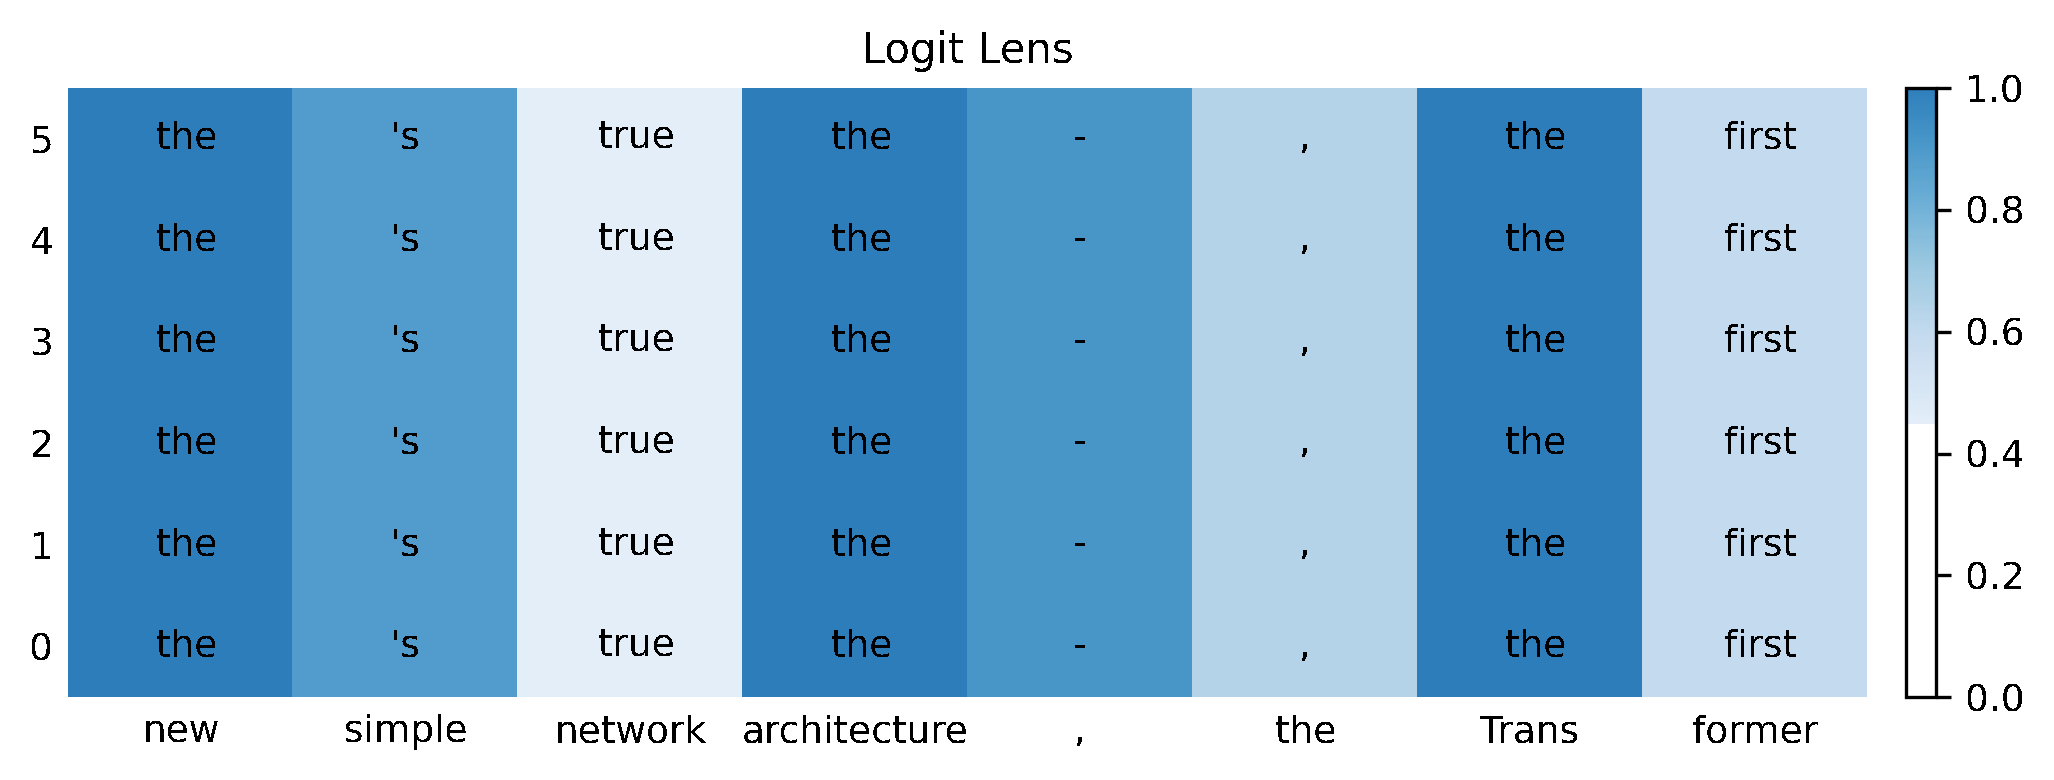

In [44]:
plot_logit_lens(df8, x_tokens=["new","simple","network","architecture",",","the","Trans","former"], title="Logit Lens")

In [ ]:
# token_i, layer_i, token, prob: 需要知道seq中第i个token，第l层，display token，以及对应的概率是什么
# test_dataset需要指定第几层，test_dataset中取一个example，(64, 768)，原始输入token已知，每一层64个seq我们可以对应索取到，只要把768转化为token和概率即可
# 得到这样一个表，再画图
# test_dataset是为训练某一层sae准备的，这种可视化，不如直接推理快一些吧

/home/b5bq/pu22650.b5bq/miniforge3/envs/qwen/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import pandas as pd
import torch

from vasae.metrics.logitlens import LogitLens
from vasae.models.factory import get_blackbox_model

In [99]:
model, tokenizer = get_blackbox_model("gpt2", "cuda")
logitlens = LogitLens(unembed_layer=model.lm_head)

In [100]:
text = "my name is Bryan, I am a huge fan of yours. I was always very impressed with you"
tokens = tokenizer(
    text,
    return_tensors="pt",
    max_length=64,
    truncation=True,
    padding="max_length",
    # return_offsets_mapping=True,  # 保存原始位置(start, end)
    add_special_tokens=True,
).to("cuda")

with torch.no_grad():
    out = model(**tokens, output_hidden_states=True,)

In [101]:
logitlens = LogitLens(unembed_layer=model.lm_head)

In [102]:
pred_tokens_per_layer = []
pred_probs_per_layer = []
for layer_i, a_l in enumerate(out.hidden_states):
    res = logitlens.top1(a_l)
    pred_tokens_per_layer.append([tokenizer.decode(res["token_ids"][0, s]) for s in range(res["token_ids"].size(1))])
    pred_probs_per_layer.append(res["token_probs"][0].detach().cpu().tolist())

In [103]:
pd.DataFrame(pred_tokens_per_layer)

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,my,name,is,Bryan,",",I,am,a,huge,fan,...,<|endoftext|>,<|endoftext|>,<|endoftext|>,<|endoftext|>,<|endoftext|>,<|endoftext|>,<|endoftext|>,<|endoftext|>,<|endoftext|>,<|endoftext|>
1,the,",",the,",",the,the,a,"""",the,fan,...,the,the,the,the,the,the,the,the,the,the
2,",",name,a,",",the,'ve,not,very,the,fan,...,the,the,the,the,the,the,the,the,the,the
3,the,name,a,",",the,'ve,not,very,",",fan,...,the,the,the,the,the,the,the,the,the,the
4,the,name,a,",",the,'ve,not,very,part,fan,...,the,the,the,the,the,the,the,the,the,the
5,the,",",a,",",the,'ve,not,very,",",the,...,the,the,the,the,the,the,the,the,the,the
6,the,",",a,",",and,can,not,very,fan,",",...,the,the,the,the,the,the,the,the,the,the
7,the,",",the,",",and,can,a,very,fan,of,...,the,the,the,the,the,the,the,the,the,the
8,the,",",the,",",and,can,a,very,fan,of,...,the,the,the,the,the,the,the,the,the,the
9,the,",",the,",",and,have,a,the,fan,of,...,the,the,the,the,the,the,the,the,the,the


In [104]:
pd.DataFrame(pred_probs_per_layer)

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.516058,0.100596,0.003258,0.063546,0.064793,0.006894,0.019790,0.006244,0.006567,0.033065,...,0.027483,0.027130,0.027055,0.027125,0.027215,0.027387,0.027421,0.027305,0.027694,0.028105
1,0.753202,0.784987,0.750878,0.693850,0.921273,0.654200,0.560852,0.554176,0.693729,0.992705,...,0.887163,0.884300,0.889007,0.886909,0.889847,0.886704,0.896513,0.891640,0.898358,0.893952
2,0.773313,0.602704,0.523456,0.841241,0.749424,0.698554,0.896579,0.770097,0.392916,0.999715,...,0.712296,0.714803,0.717879,0.718966,0.715779,0.718660,0.723281,0.719835,0.723630,0.721932
3,0.989111,0.572100,0.681301,0.927305,0.803320,0.902292,0.907357,0.919770,0.547796,0.994602,...,0.918162,0.918247,0.918449,0.917964,0.918079,0.916605,0.915605,0.914915,0.915165,0.914718
4,0.993537,0.796869,0.740023,0.974526,0.725775,0.749638,0.832807,0.982405,0.338589,0.758505,...,0.947501,0.946986,0.946922,0.945715,0.945773,0.944005,0.943327,0.941839,0.942427,0.941661
5,0.994235,0.999267,0.707826,0.997326,0.525268,0.716079,0.987743,0.958566,0.858392,0.370437,...,0.946777,0.942631,0.938170,0.931781,0.925415,0.918478,0.914917,0.906774,0.906235,0.900848
6,0.992426,0.999985,0.868826,0.999451,0.862057,0.739067,0.907082,0.994859,0.900841,0.493572,...,0.909012,0.906311,0.902095,0.896286,0.892964,0.886114,0.882727,0.876816,0.877354,0.874806
7,0.990214,0.999999,0.539091,0.999886,0.884784,0.940202,0.671100,0.994408,0.997625,0.537970,...,0.880780,0.876294,0.871824,0.863143,0.858727,0.850349,0.844923,0.838881,0.837115,0.833921
8,0.986610,1.000000,0.905305,0.999999,0.880487,0.620491,0.976373,0.986596,0.984877,0.949957,...,0.902145,0.895555,0.889547,0.880495,0.873213,0.864392,0.861506,0.851392,0.850956,0.844017
9,0.975261,1.000000,0.995941,1.000000,0.910011,0.972786,0.892571,0.982708,0.999996,0.999935,...,0.919669,0.917725,0.915741,0.911927,0.909375,0.905787,0.905099,0.901682,0.902273,0.901112


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_logit_lens_lists(
    tokens_by_layer,   # List[L][S]
    probs_by_layer,    # List[L][S]
    title=None,
    fontsize=9,
    dpi=300,
    cbar_ticks=(0,0.2,0.4,0.6,0.8,1),
):
    Z = np.array(probs_by_layer)[::-1]    # 高层在上
    T = np.array(tokens_by_layer)[::-1]

    H, W = Z.shape
    y_labels = list(range(len(tokens_by_layer)))[::-1]

    # x token = 第0层（输入token）
    x_tokens = tokens_by_layer[0]

    fig_w = max(1.2, 0.9 * W)
    fig_h = max(1.2, 0.45 * H)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)

    norm = mcolors.Normalize(Z.min(), Z.max())
    cmap = clip_cmap(plt.cm.Blues, lo=0.1, hi=0.7)

    im = ax.imshow(
        Z,
        cmap=cmap,
        norm=norm,
        interpolation="none",
        aspect="auto",
        origin="upper",
    )

    # cell text
    for i in range(H):
        for j in range(W):
            ax.text(
                j, i, T[i, j],
                ha="center", va="center",
                fontsize=fontsize,
            )

    # x axis
    ax.set_xticks(range(W))
    ax.set_xticklabels(x_tokens, fontsize=fontsize)
    ax.tick_params(axis="x", pad=4)

    # y axis
    yt = np.linspace(0, H-1, min(6, H), dtype=int)
    ax.set_yticks(yt)
    ax.set_yticklabels([y_labels[i] for i in yt], fontsize=fontsize)

    # clean
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0)
    ax.grid(False)

    if title:
        ax.set_title(title, fontsize=fontsize+1, pad=6)

    cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_ticks(cbar_ticks)
    cbar.ax.tick_params(labelsize=fontsize)

    plt.tight_layout(rect=[0,0,0.97,1])
    plt.show()